# API 入门



## 1. 什么是API？


### 1.1 生活中的API类比

想象一下去餐厅用餐的体验：

- **传统方式**：您需要走进厨房，告诉厨师要做什么菜，如何烹饪
- **现代方式**：通过菜单点餐，服务员将您的需求传达给厨房

**API就是数字世界的"菜单和服务员"**，它让不同的软件系统能够相互沟通，而无需了解对方内部的复杂细节。

### 1.2 API的正式定义

API（Application Programming Interface）中文译为"应用程序编程接口"，是一套标准化的规则和工具，让不同的软件能够安全、高效地交换数据和功能。



## 2. 为什么API对商业人士很重要？



### 2.1 现实商业价值

- **数据驱动决策**：实时获取市场数据、客户信息
- **流程自动化**：连接不同系统，减少人工操作
- **创新加速**：快速集成第三方服务，提升产品竞争力
- **成本优化**：无需自建复杂系统，按需使用专业服务

### 2.2 实际应用场景

| 应用领域 | API用途 | 商业价值 |
|---------|---------|----------|
| 金融服务 | 股票数据、支付接口 | 实时决策、交易自动化 |
| 市场营销 | 客户数据、社交媒体 | 精准营销、客户洞察 |
| 供应链 | 物流跟踪、库存管理 | 流程优化、成本控制 |
| 人力资源 | 招聘平台、考勤系统 | 效率提升、数据分析 |



## 3. 动手体验：从零开始使用API



### 3.1 准备工作：安装必要工具


In [2]:
# 这些代码已经为您准备好，直接运行即可
# 首先安装必要的库
# !pip install requests pandas

# 导入工具包
import requests
print("环境准备完成！")

环境准备完成！



### 3.2 第一个API调用：获取随机用户数据



In [4]:
response = requests.get('https://randomuser.me/api/')        
# 解析返回的数据
data = response.json()
print(data)

{'results': [{'gender': 'male', 'name': {'title': 'Monsieur', 'first': 'Silvan', 'last': 'Dubois'}, 'location': {'street': {'number': 6058, 'name': 'Boulevard de la Duchère'}, 'city': 'Daillens', 'state': 'Appenzell Ausserrhoden', 'country': 'Switzerland', 'postcode': 3488, 'coordinates': {'latitude': '-59.0304', 'longitude': '-9.4794'}, 'timezone': {'offset': '+5:45', 'description': 'Kathmandu'}}, 'email': 'silvan.dubois@example.com', 'login': {'uuid': 'e3b92312-3416-4f07-9e9a-f2e246d99301', 'username': 'organicostrich968', 'password': 'todd', 'salt': 'lsfA0cBh', 'md5': '7d92bda775fbf8f3d09ad893e0e65d32', 'sha1': '7ad5d8d21c9915911d3ba8d6bbf44bce5179ce14', 'sha256': 'ff60a7e2fe35fbca4908377ca8328b513d7374bb77aefc315a04936931664797'}, 'dob': {'date': '1954-11-19T04:29:44.343Z', 'age': 71}, 'registered': {'date': '2020-05-11T23:57:31.786Z', 'age': 5}, 'phone': '077 856 10 16', 'cell': '079 147 25 53', 'id': {'name': 'AVS', 'value': '756.0694.5578.46'}, 'picture': {'large': 'https://rand

In [5]:
# 示例1：获取随机用户信息（用于测试和演示）
def get_random_user():
    # 向API发送请求
    response = requests.get('https://randomuser.me/api/')
    
    # 解析返回的数据
    data = response.json()
    
    # 提取有用信息
    user = data['results'][0]
    user_info = {
        '姓名': f"{user['name']['first']} {user['name']['last']}",
        '性别': user['gender'],
        '邮箱': user['email'],
        '城市': user['location']['city'],
        '国家': user['location']['country']
    }
    
    return user_info

# 调用函数并显示结果
user_data = get_random_user()
print("获取到的用户信息：")
for key, value in user_data.items():
    print(f"{key}: {value}")

获取到的用户信息：
姓名: Ricky Price
性别: male
邮箱: ricky.price@example.com
城市: Portsmouth
国家: United Kingdom



### 3.3 理解API调用过程


请求流程：
您的代码 → 发送请求 → API服务器 → 处理请求 → 返回数据 → 您的代码

关键要素：
1. 端点(Endpoint)：API的"网址"
2. 参数(Parameters)：告诉API您要什么
3. 响应(Response)：API返回的结果



## 4. 商业数据分析实战：获取股票信息



### 4.1 安装金融数据工具


In [6]:
# 安装金融数据分析库。考虑到yfinance有时会遇到访问限制问题，建议使用akshare库
# pip install akshare --upgrade -i https://pypi.tuna.tsinghua.edu.cn/simple
# pip install pandas --upgrade -i https://pypi.tuna.tsinghua.edu.cn/simple
import akshare as ak  
import pandas as pd
import datetime
print("金融数据分析环境准备完成！")


金融数据分析环境准备完成！



### 4.2 获取A股公司股票数据


akshare使用的是东方财富网的数据库接口，但是近期东方财富网反爬虫较为严格，如果多次请求失败请等待一段时间再尝试。

具体接口链接参考：https://akshare.akfamily.xyz/data/stock/stock.html#id23

In [ ]:
# 示例2：获取A股公司股票数据
def get_stock_data(symbol, period="1y"):
    """
    获取股票历史数据
    symbol: A股代码（如：000001）
    period: 时间周期（1y=1年，6mo=6个月）
    """
    # 计算日期
    end_date = datetime.datetime.now().strftime("%Y%m%d")
    if period == "1y": # 最近一年
        start_date = (datetime.datetime.now() - datetime.timedelta(days=365)).strftime("%Y%m%d")
    elif period == "6mo": # 最近六个月
        start_date = (datetime.datetime.now() - datetime.timedelta(days=180)).strftime("%Y%m%d")
    else:
        start_date = "20200101" # 默认起始日期
    try:
        # 使用 akshare 获取A股数据
        df = ak.stock_zh_a_hist(symbol=symbol, period="daily", start_date=start_date, end_date=end_date, adjust="qfq")
        
        if df.empty:
            raise ValueError("未获取到数据，请检查股票代码")
        
        # 重命名列（akshare A股列名：日期, 开盘, 收盘, 最高, 最低, 成交量, 成交额, 振幅, 涨跌幅, 涨跌额, 换手率）
        df = df.rename(columns={'开盘': 'Open', '最高': 'High', '最低': 'Low', '收盘': 'Close', '成交量': 'Volume'})
        simplified_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        simplified_data['日期'] = pd.to_datetime(df['日期'])
        simplified_data.set_index('日期', inplace=True)
        
        return simplified_data
    except Exception as e:
        print(f"获取数据失败：{e}")
        return pd.DataFrame()

# 获取平安银行最近一年的股票数据（A股代码：000001）
# 多次请求容易出错，建议适当等待
pingan_data = get_stock_data("000001", "1y")
if not pingan_data.empty:
    print("平安银行股票数据（最近5个交易日）：")
    print(pingan_data.tail())
else:
    print("未能获取到数据。")

平安银行股票数据（最近5个交易日）：
             Open   High    Low  Close   Volume
日期                                             
2025-11-18  11.65  11.69  11.57  11.59   670077
2025-11-19  11.58  11.83  11.57  11.80  1334996
2025-11-20  11.79  11.99  11.74  11.85  1637040
2025-11-21  11.80  11.88  11.66  11.69  1465359
2025-11-24  11.70  11.73  11.60  11.60  1117119


### 4.3 数据解读与商业分析


In [53]:
# 计算基本统计指标
def analyze_stock(data):
    latest_close = data['Close'].iloc[-1]
    highest = data['Close'].max()
    lowest = data['Close'].min()
    avg_volume = data['Volume'].mean()
    
    print(f"当前股价: ¥{latest_close:.2f}")
    print(f"年内最高: ¥{highest:.2f}")
    print(f"年内最低: ¥{lowest:.2f}")
    print(f"平均成交量: {avg_volume:,.0f} 股")
    
    # 计算涨跌幅
    first_price = data['Close'].iloc[0]
    price_change = ((latest_close - first_price) / first_price) * 100
    print(f"期间涨跌幅: {price_change:+.2f}%")

# 分析平安银行股票
analyze_stock(pingan_data)

当前股价: ¥11.60
年内最高: ¥12.94
年内最低: ¥10.10
平均成交量: 1,143,819 股
期间涨跌幅: +9.64%



## 5. API在商业智能中的应用



### 5.1 市场情报收集


In [98]:
# 示例3：多股票对比分析
def compare_stocks(symbols, period="6mo"):
    comparison = {}
    
    for symbol in symbols:
        stock_data = get_stock_data(symbol, period)
        latest_price = stock_data['Close'].iloc[-1]
        comparison[symbol] = latest_price
    
    # 创建对比表格
    comparison_df = pd.DataFrame(list(comparison.items()), 
                               columns=['股票代码', '当前价格：元'])
    
    return comparison_df

# 对比多家A股公司
a_stocks = ['000001', '000002', '600000', '000858']  # 平安银行、万科A、浦发银行、五粮液
a_comparison = compare_stocks(a_stocks)
print("A股价格对比：")
print(a_comparison)

A股价格对比：
     股票代码  当前价格：元
0  000001   11.60
1  000002    6.04
2  600000   11.53
3  000858  118.52


### 5.2 数据可视化（可选）


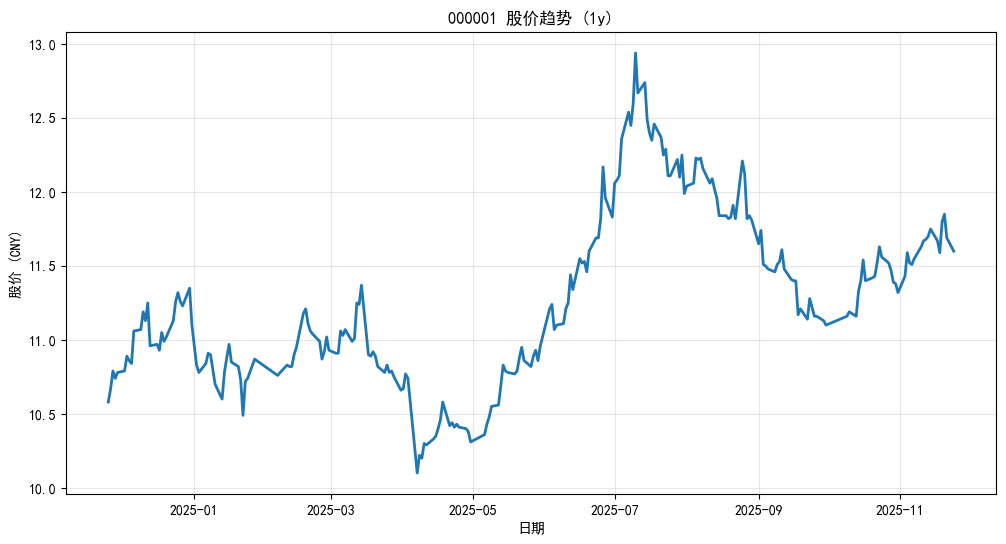

In [ ]:
# 进阶功能：数据可视化
# pip install matplotlib --upgrade -i https://pypi.tuna.tsinghua.edu.cn/simple  
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # 这一行和下一行用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False
# 绘制股价趋势图
def plot_stock_trend(symbol, period="1y"):
    data = get_stock_data(symbol, period)
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'], linewidth=2)
    plt.title(f'{symbol} 股价趋势 ({period})')
    plt.xlabel('日期')
    plt.ylabel('股价 (CNY)')
    plt.grid(True, alpha=0.3)
    plt.show()

# 示例：绘制平安银行股价图
# 这里多次请求容易出错，建议适当等待
plot_stock_trend("000001")


## 6. API的类型和使用注意事项


### 6.1 不同类型的API

| API类型 | 特点 | 适用场景 |
|---------|------|----------|
| 开放API | 免费使用，无需注册 | 学习、测试、小项目 |
| 注册API | 需要账号，有免费额度 | 商业分析、个人项目 |
| 付费API | 功能强大，服务质量高 | 企业应用、生产环境 |

### 6.2 使用API的最佳实践

1. **安全第一**：妥善保管API密钥
2. **尊重限制**：遵守调用频率限制
3. **错误处理**：准备好应对API不可用的情况
4. **数据备份**：重要数据及时保存
5. **遵守条款**：尊重服务提供商的使用协议

### 6.3 常见API错误处理



In [75]:
# 安全的API调用方式
def safe_api_call(url):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # 检查请求是否成功
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"API调用失败: {e}")
        return None

# 使用安全调用
user_data = safe_api_call('https://randomuser.me/api/')
if user_data:
    print("API调用成功！")
else:
    print("请检查网络连接或稍后重试")



API调用成功！



## 7. 商业应用展望



### 7.1 API在您业务中的潜在应用

- **客户关系管理**：集成邮件营销、客户服务系统
- **财务分析**：实时获取市场数据，自动化报告生成
- **运营优化**：连接物流、库存、供应商系统
- **竞争情报**：监控市场动态、竞争对手信息

### 7.2 下一步学习建议

1. **从简单开始**：先使用不需要注册的开放API
2. **选择相关领域**：根据您的业务选择相关的API服务
3. **循序渐进**：从数据获取开始，逐步学习数据处理和分析
4. **寻求帮助**：多查阅官方文档，加入相关社区


## 总结
API是现代商业的"连接器"，它让：
- **数据流动**：打破信息孤岛
- **系统协作**：提升运营效率  
- **创新加速**：快速集成先进技术

**记住**：您不需要成为技术专家，但了解这些工具如何工作，将让您在数字时代更具竞争力。
